# Chapter 3. 그래프 인과모델

Chapter 3는 인과 추론의 핵심 언어인 그래프 인과모델을 소개한다. 데이터만으로는 드러나지 않는 인과 가정을 명시적으로 표현하고, 어떤 변수를 통제해야 편향이 사라지는지 체계적으로 판단하게 해준다.

## 그래프 인과모델(Graphical Causal Models) 개요
- DAG : 인과 그래프. DAG는 유향 비순환 그래프(directed acyclic graph)의 약자. 방향이 있는 부분은 없는 부분과 달리, 소셜 미디어처럼 엣지(edge)에 방향성을 나타냄.
- 비순환 부분은 그래프에 루프타 순환(cycle)이 없음을 의미. 인과관계에서는 되돌릴 수 없는 비가역적(nonreversible) 가정이 있으므로 인과 그래프는 일반적으로 **방향성 있는 비순환 그래프**  

그래프 인과모델은 변수들 간의 인과구조를 DAG(Directed Acyclic Graph)로 표현한다. DAG의 방향성은 원인에서 결과로 향하고, 순환이 없기 때문에 명확한 시간적·논리적 순서를 가정한다.  
각 그래프는 다음 두 가지 성질을 만족할 때 인과모델로 해석할 수 있다.

- **Markov 성질**: 그래프 구조만으로 조건부 독립 관계를 읽어낼 수 있다.
- **충분성 가정**: 그래프에 포함된 변수만으로 주요 인과 경로를 설명할 수 있다고 가정한다.

## 핵심 구성 요소

### 1. 노드(Nodes): 변수들
- 관심 있는 개체·속성·이벤트를 나타내는 정점
- 예: 흡연, 폐암, 나이, 유전

### 2. 엣지(Edges): 인과관계
- 화살표(→)는 원인에서 결과로 향하는 직접적인 인과 효과를 의미
- X → Y: “X가 변하면, 다른 요인이 고정되었을 때 Y도 바뀐다”

### 3. 경로(Paths)
- 노드와 엣지가 연결된 임의의 경로로, 인과적(방향 일치)일 수도 있고 비인과적(교란 경로)일 수도 있다.

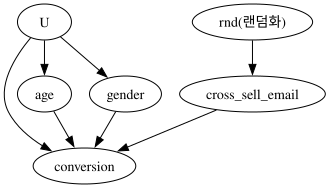

In [5]:
import graphviz as gr

g_cross_sell = gr.Digraph()
g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "age")
g_cross_sell.edge("U", "gender")

g_cross_sell.edge("rnd(랜덤화)", "cross_sell_email")
g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("age", "conversion")
g_cross_sell.edge("gender", "conversion")

g_cross_sell

- 처치 T : 교차 판매 이메일
- U : 측정되지 않으나 전환을 유도하는 관측되지 않는 변수들
- 결과 Y : 고객이 신규 제품으로의 전환 여부  

그래프는 연관관계는 인과관계가 아닌 이유를 이해하기 위한 강력한 도구

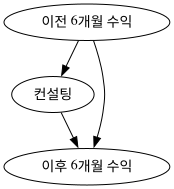

In [6]:
# 또다른 사례 : 컨선턴트 영입 여부 결정
g = gr.Digraph()
g.edge("이전 6개월 수익", "컨설팅")
g.edge("이전 6개월 수익", "이후 6개월 수익")
g.edge("컨설팅", "이후 6개월 수익")

g

## 3가지 그래프 구조
- 그래프 모델에 어떤 독립성 및 조건부 독립성 가정이 수반되는지 이해하는 게 중요함

### (1) 사슬(chain) 구조
- 체인 구조라고도 부름
- 예: 흡연 → 폐 손상 → 폐암
- 체인 구조에서는 중간 변수를 통제하면 원인과 결과 간의 인과 효과를 분리할 수 있음


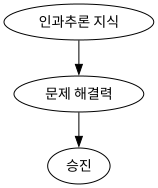

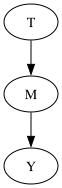

In [11]:
g = gr.Digraph()
g.edge("인과추론 지식", "문제 해결력")
g.edge("문제 해결력", "승진")
display(g)

g2 = gr.Digraph()
g2.edge("T", "M")
g2.edge("M", "Y")
display(g2)

- T는 M의 원인이 되고, M은 Y의 원인이 됨
- 중간 노드(intermediary node)는 T와 Y 사이의 관계를 매개하는 역할로, **매개자(mediator)**라고 부름
- 인과관계는 화살표 방향으로만 흐르지만 연관관계는 양방향으로 흐름
- 매개자를 고정하면?
    - 그래프에서 변수를 고정하는 것은 특정 변수의 값을 일정하게 유지하면서 다른 변수들 간의 관계를 관측하는 것을 의미
    - 매개자를 통제하면 원인과 결과 간의 인과 효과를 분리할 수 있음  


$E[승진|문제 해결력, 인과추론 지식] = E[승진|문제 해결력]$
- "문제 해결력이 같은 수준이라면, 인과추론 지식이 많든 적든 승진 확률은 동일하다"
- 문제 해결력(M)을 고정하면:
    - 인과추론 지식(T)이 승진(Y)에 미치는 경로가 차단됨
    - 인과추론의 효과는 오직 문제 해결력을 통해서만 전달되기 때문
    - 문제 해결력이 이미 고정되어 있으면, 인과추론 지식은 더 이상 승진에 영향을 줄 수 없음

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 시뮬레이션
np.random.seed(42)
n = 1000

# T → M → Y (완전 매개)
T = np.random.normal(100, 15, n)  # 인과추론 지식 점수
M = 0.7 * T + np.random.normal(0, 10, n)  # 문제 해결력 (T의 영향 받음)
Y = 0.5 * M + np.random.normal(0, 5, n)  # 승진 점수 (M의 영향만 받음, T 직접 효과 없음)

df = pd.DataFrame({
    '인과추론_지식': T,
    '문제_해결력': M,
    '승진_점수': Y
})

# 분석 1: 총 효과 (M 통제 안 함)
model1 = LinearRegression()
model1.fit(df[['인과추론_지식']], df['승진_점수'])
print(f"총 효과 (M 통제 안 함): {model1.coef_[0]:.4f}")
# 결과: 유의미한 양수 (인과추론이 승진에 영향 있음)

# 분석 2: 직접 효과 (M 통제)
model2 = LinearRegression()
model2.fit(df[['인과추론_지식', '문제_해결력']], df['승진_점수'])
print(f"직접 효과 (M 통제): {model2.coef_[0]:.4f}")
print(f"M의 효과: {model2.coef_[1]:.4f}")
# 결과: 인과추론의 계수가 0에 가까움 (효과 사라짐)
#       문제 해결력의 계수는 유의미함

총 효과 (M 통제 안 함): 0.3437
직접 효과 (M 통제): 0.0108
M의 효과: 0.4949


- 총 효과(M 통제 안 함) 
    - 인과추론 지식이 1점 증가하면 → 승진 점수가 0.3437점 증가
    - 문제 해결력을 고려하지 않은 전체 효과
- 직접효과 (M 통제))
    - 문제 해결력이 같은 사람들끼리 비교했을 때
    - 인과추론 지식이 1점 증가하면 → 승진 점수가 고작 0.0108점 증가
    - 이건 거의 0에 가까운 값 (통계적으로 유의하지 않을 가능성 높음)
- M의 효과
    - 인과추론 지식이 같은 사람들끼리 비교했을 때
    - 문제 해결력이 1점 증가하면 → 승진 점수가 0.4949점 증가
    - 이건 매우 강력한 효과!

### (2) 분기(fork) 구조

- 분기 구조에는 공통 원인이 있음
- 같은 변수가 그래프 아래쪽 다른 두 변수의 원인이 됨
- 분기 구조에서 연관성은 화살표의 반대 방향으로 흐름
- 처치와 결과 사이에 공통 원인 => **교란 요인(confounder)**

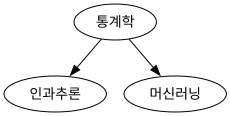

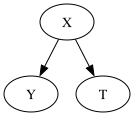

In [16]:
g = gr.Digraph()
g.edge("통계학", "인과추론")
g.edge("통계학", "머신러닝")
display(g)

g2 = gr.Digraph()
g2.edge("X", "Y")
g2.edge("X", "T")
display(g2)

### 구조: T ← X → Y


**핵심 특징:**
- X가 T와 Y의 공통 원인 (Common Cause)
- T와 Y 사이에 직접적인 인과관계는 없음
- 하지만 X를 통해 T와 Y가 연관되어 보임 (가짜 상관관계)

### 교란변수(Confounder)의 문제

**X를 통제하지 않으면:**
- T와 Y 사이에 상관관계가 관측됨
- `Corr(T, Y) ≠ 0` → 마치 T가 Y의 원인인 것처럼 보임!
- 이것은 **가짜 상관관계(Spurious Correlation)**

**X를 통제하면:**
- T와 Y 사이의 경로가 차단됨 (Blocked)
- `T ⟂ Y | X` → T와 Y는 X가 주어졌을 때 독립
- `Corr(T, Y | X) = 0` → 진짜 인과관계가 없음을 확인

### 실제 예시

**예시 1: 아이스크림과 익사 사고**
```
    기온(X)
   ↙     ↘
아이스크림   익사사고
판매량(T)    (Y)
```
- 아이스크림 판매량과 익사 사고가 상관관계 있음
- 하지만 아이스크림이 익사를 유발하지는 않음!
- 공통 원인: 기온 (더운 날 둘 다 증가)
- 기온을 통제하면 상관관계 사라짐

**예시 2: 통계학 지식**
```
   통계학(X)
   ↙      ↘
인과추론(T)  머신러닝(Y)
```
- 인과추론을 잘하는 사람이 머신러닝도 잘함 (상관관계 있음)
- 하지만 인과추론이 머신러닝을 직접 유발하지는 않음
- 공통 원인: 통계학 기초 지식
- 같은 통계학 수준에서 비교하면 독립적일 수 있음

**예시 3: 커피와 폐암**
```
    흡연(X)
   ↙     ↘
 커피(T)   폐암(Y)
```
- 커피를 많이 마시는 사람이 폐암 발병률이 높음
- 하지만 커피가 폐암을 유발하는 것이 아님!
- 공통 원인: 흡연 (흡연자가 커피를 더 많이 마심)
- 흡연 여부를 통제하면 커피와 폐암의 상관관계 사라짐

### 사슬 구조와의 차이점

| 구조 | 형태 | 화살표 방향 | 통제 시 효과 | 목적 |
|------|------|------------|------------|------|
| 사슬 | T → M → Y | 일방향 | 경로 차단, 효과 사라짐 | 매개 효과 분석 |
| 분기 | T ← X → Y | 양방향 발산 | 경로 차단, 편향 제거 | 교란 통제 |

**사슬 구조**: 중간 변수를 **통제하면 안 됨** (진짜 효과가 사라짐)  
**분기 구조**: 공통 원인을 **반드시 통제해야 함** (가짜 상관 제거)

### 분기 구조에서 인과 효과 추정

**잘못된 분석 (X 통제 안 함):**
```python
# T와 Y의 단순 상관관계 (편향됨!)
model = "Y ~ T"
# → T의 계수가 유의미하게 나오지만 이는 X 때문
```

**올바른 분석 (X 통제):**
```python
# X를 통제하여 교란 제거
model = "Y ~ T + X"
# → T의 계수가 0에 가까워짐 (진짜 효과 없음 확인)
```

### 왜 연관성이 화살표 반대로 흐를까?

```
    X
   ↙ ↘
  T   Y
```

1. X가 증가하면 → T가 증가 (X → T)
2. X가 증가하면 → Y가 증가 (X → Y)
3. 따라서 T가 큰 값일 때 Y도 큰 값 (T ↔ Y 상관)
4. 하지만 이는 X를 통한 간접적 연관일 뿐, 직접 인과는 아님

**정보 흐름:**
- 인과관계: X → T, X → Y (화살표 방향)
- 연관관계: T ↔ Y (X를 통해 양방향으로 정보 공유)

### d-separation 규칙

**분기 구조에서:**
- X를 조건화하지 않으면: 경로 열림 (T와 Y 연관)
- X를 조건화하면: 경로 차단 (T ⟂ Y | X)

이는 공통 원인을 통제하면 가짜 상관관계를 제거할 수 있다는 의미입니다.

### 실무 적용

**Step 1:** DAG 그리기
```
내가 관심있는 T → Y 관계에서
둘 다에 영향을 주는 X가 있는가?
```

**Step 2:** 교란변수 식별
```
T ← X → Y 구조 찾기
```

**Step 3:** 통제 변수 선정
```
회귀 분석에 X를 포함시켜 통제
```

**Step 4:** 인과 효과 추정
```
X를 통제한 상태에서 T의 계수 확인
```

### (3) 충돌부(collider) 구조
- 충돌변수(collider)는 두 개 이상의 화살표가 모여드는 변수
- 충돌부 구조는 두 노드가 하나의 자식(child)을 공유하지만, 그들 사이에 직접적인 관계가 없는 경우
- 예: 재능 → 성공 ← 노력
- 충돌변수를 조건화하면 인위적으로 상관을 만들어 편향이 유발된다(선택 편향).
- 충돌부 구조에서 두 부모 노드는 서로 독립적.
    - But, 공통 효과를 조건부로 두면 서로 종속이 됨


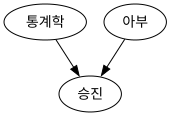

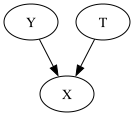

In [19]:
g = gr.Digraph()
g.edge("통계학", "승진")
g.edge("아부", "승진")
display(g)

g2 = gr.Digraph()
g2.edge("Y", "X")
g2.edge("T", "X")
display(g2)

### 구조: T → X ← Y

```
  T   Y
   ↘ ↙
    X (충돌변수)
```

**핵심 특징:**
- X가 T와 Y의 공통 결과 (Common Effect)
- T와 Y 사이에 직접적인 인과관계는 없음
- T와 Y는 원래 **독립적**
- 하지만 X를 통제하면 T와 Y가 **인위적으로 종속**됨

### 충돌변수의 역설 (Collider Bias)

**사슬/분기 구조와 정반대!**

**X를 통제하지 않으면:**
- T와 Y 사이에 상관관계 **없음**
- `Corr(T, Y) = 0` ✓ (진짜 독립)
- `T ⟂ Y` → 경로가 차단되어 있음

**X를 통제하면:**
- T와 Y 사이에 상관관계가 **생김**!
- `Corr(T, Y | X) ≠ 0`  (가짜 상관)
- `T ⫫ Y | X` → 경로가 열림
- 이것이 **선택 편향(Selection Bias)** 또는 **충돌 편향(Collider Bias)**

### 왜 이런 일이 발생할까?

**직관적 설명:**

X를 통제한다는 것은 "X가 특정 값인 샘플만 본다"는 의미.

```
재능(T) → 성공(X) ← 노력(Y)
```

**전체 모집단:**
- 재능과 노력은 독립적 (재능 있다고 노력을 더 하거나 덜 하지 않음)

**성공한 사람만 봤을 때:**
- 재능이 낮으면 → 노력이 높아야 성공
- 재능이 높으면 → 노력이 낮아도 성공
- 따라서 재능과 노력이 **음의 상관관계**로 보임!
- "성공한 사람 중에는 재능 있으면 노력을 덜 한다"는 착각

### 실제 예시

**예시 1: 재능과 노력**
```
  재능(T)   노력(Y)
     ↘     ↙
      성공(X)
```

**전체 인구:**
- 재능과 노력은 독립적
- `Corr(재능, 노력) = 0` ✓

**성공한 사람만 조사하면:**
- 재능 있는 사람: 노력 적어도 성공
- 재능 없는 사람: 노력 많이 해야 성공
- `Corr(재능, 노력 | 성공) < 0` (음의 상관!)
- **"성공한 사람 중에는 재능 있으면 게으르다"는 잘못된 결론**

**예시 2: 통계학과 아부**
```
  통계학(T)   아부(Y)
      ↘      ↙
       승진(X)
```

**전체 직원:**
- 통계학 실력과 아부는 독립적
- `Corr(통계학, 아부) = 0` ✓

**승진한 사람만 조사하면:**
- 통계학 잘하는 사람: 아부 안 해도 승진
- 통계학 못하는 사람: 아부 열심히 해야 승진
- `Corr(통계학, 아부 | 승진) < 0` (음의 상관!)
- **"승진한 사람 중에는 실력 있으면 아부를 안 한다"는 잘못된 결론**

**예시 3: 미모와 실력 (할리우드 편향)**
```
   미모(T)   연기력(Y)
      ↘      ↙
     배우 선발(X)
```

**전체 지원자:**
- 미모와 연기력은 독립적

**선발된 배우만 보면:**
- 미모가 뛰어난 배우: 연기력 부족해도 선발
- 미모가 평범한 배우: 연기력 뛰어나야 선발
- **"배우 중에는 미인이면 연기를 못한다"는 편향**

**예시 4: 건강과 의료비**
```
  건강(T)   소득(Y)
     ↘     ↙
    입원(X)
```

**전체 인구:**
- 건강 상태와 소득은 (직접적으로는) 독립적

**입원 환자만 조사하면:**
- 건강이 매우 나쁜 사람: 소득 낮아도 입원
- 건강이 약간 나쁜 사람: 소득 높아야 입원 (병원비 감당 가능)
- 건강과 소득이 양의 상관관계로 보임
- **입원 환자만 보면 왜곡된 관계 발견**

### 세 가지 구조 비교

| 구조 | 형태 | 부모 관계 | 통제하지 않으면 | 통제하면 | 목적 |
|------|------|----------|----------------|---------|------|
| 사슬 | T → M → Y | 인과 경로 | T와 Y 연관 | T와 Y 독립 | 매개 분석 |
| 분기 | T ← X → Y | 공통 원인 | T와 Y 연관 (가짜) | T와 Y 독립 (진짜) | 교란 제거 |
| 충돌 | T → X ← Y | 독립적 | T와 Y 독립 (진짜) | T와 Y 연관 (가짜) | 선택 편향 회피 |

**핵심 차이:**
- **사슬/분기**: 통제하지 않으면 연관, 통제하면 독립
- **충돌**: 통제하지 않으면 독립, 통제하면 연관 (정반대!)

### d-separation 규칙

**충돌 구조에서:**
- X를 조건화하지 않으면: 경로 **차단됨** (T ⟂ Y)
- X를 조건화하면: 경로 **열림** (T ⫫ Y)
- X의 후손(descendant)을 조건화해도: 경로 **열림**

이는 충돌변수나 그 후손을 통제하면 가짜 상관관계가 생긴다는 의미!

### 충돌부 편향을 피하는 방법

**잘못된 분석:**
```python
# 충돌변수를 통제 (선택 편향 발생!)
df_selected = df[df['성공'] == 1]  # 성공한 사람만 선택
model = "노력 ~ 재능"  # 잘못된 음의 상관 발견
```

**✓ 올바른 분석:**
```python
# 충돌변수를 통제하지 않음
df_all = df  # 전체 데이터 사용
model = "노력 ~ 재능"  # 진짜 독립 관계 확인
```

### 실무에서 주의할 점

**1. 샘플 선택 편향**
```
설문 응답자만 분석 → 응답(충돌변수) 통제
특정 병원 환자만 분석 → 입원(충돌변수) 통제
승진자만 분석 → 승진(충돌변수) 통제
```

**2. 회귀 분석에서**
```python
# 나쁜 예: 결과 변수를 독립 변수로
model = "재능 ~ 노력 + 성공"  # 성공(결과)을 통제 X

# 좋은 예: 결과 변수를 통제하지 않음
model = "성공 ~ 재능 + 노력"  # 올바른 방향 ✓
```

**3. 층화 분석(Stratification)**
```python
# 충돌변수로 층화하지 말 것
for 성공_여부 in [0, 1]:  # X 충돌변수로 층화
    분석(df[df['성공'] == 성공_여부])
```

### 정보 흐름의 역설

```
  T   Y
   ↘ ↙
    X
```

**인과 흐름 (화살표 방향):**
- T → X, Y → X (X로 정보가 흘러감)
- T와 Y는 직접 연결 없음

**조건부 정보 흐름 (역방향!):**
- X를 알게 되면 → T와 Y 사이에 정보가 역으로 흐름
- "X = 성공"이라는 정보가 T와 Y를 연결시킴
- X가 특정 값이라는 제약이 T와 Y 사이에 통계적 종속성 생성

### 실무 적용 가이드

**Step 1:** 충돌변수 식별
```
분석에 포함된 변수 중
"두 개 이상의 화살표를 받는 변수"는?
```

**Step 2:** 선택 과정 점검
```
데이터 수집/샘플링 과정에서
특정 조건으로 필터링했는가?
→ 그 조건이 충돌변수일 수 있음
```

**Step 3:** 통제 변수 재검토
```
회귀 분석에 포함된 변수가
실제로는 결과 변수가 아닌가?
→ 충돌변수를 통제하고 있을 수 있음
```

**Step 4:** 민감도 분석
```
충돌변수를 제외/포함했을 때
결과가 어떻게 달라지는지 확인
```

### 충돌부 편향의 심각성

충돌부 편향은 **매우 교묘**
- 통계적으로 유의미한 결과를 만들어냄
- 논리적으로도 그럴듯해 보임
- 실제로는 완전히 잘못된 인과 추론

**예:**
- "성공한 사람 중에는 실력 있으면 성격이 나쁘다"
- "유명한 배우는 미인이거나 연기파다"
- "입원 환자 중 부자는 건강이 더 나쁘다"

모두 충돌부 편향으로 인한 착각일 수 있음

### (4) 조건부 독립성 가정과 보정 공식
- 조건부 독립성 가정(CIA)은 공변량 X 수준이 동일한 대상(회사)을 비교하면 잠재적 결과는 평균적으로 같음을 의미. 즉, 공변량 X 값이 동일한 대상을 보면 처치가 마치 무작위로 배정된 것처럼 보임
    - 독립성 가정은 무시가능성, 외생성, 교환가능성 등으로 불림
- 처치가 X 그룹 내에서 마치 무작위로 배정된 것처럼 보인다면, X로 정의된 각 그룹 내에서 실험군과 대조군을 비교하고 각 그룹의 크기를 가중치로 사용해서 해당 결과의 평균을 구하는 간단한 방법으로 관측 가능한 데이터에서 인과효과를 식별할 수 있음
    - $ATE = E_x[E[Y | T = 1] - E[Y | T = 0]]$
    - $ATE = \sum_x {(E[Y | T = 1, X = x] - E[Y | T = 0, X = x])P(X = x)}$  
              $= \sum_x {E[Y | T = 1, X = x]P(X = x) - E[Y | T = 0, X = x]P(X = x)}$
    - 이를 보정공식 또는 조건부 원칙이라고 함
    - 이에 따르면, X를 조건부로 두거나 통제하면 평균 처치효과는 실험군과 대조군 간 그룹 내 차이의 가중평균으로 식별할 수 있음
    - 즉, 그래프에서 비인과 경로를 통한 연관성 흐름을 X에 조건부로 두어 차단하면 ATE와 같은 인과 추정량을 식별할 수 있음
    - 교란요인을 보정하여 뒷문 경로를 차단하는 과정을 **뒷문 보정**이라고 함
    

### (5) 양수성 가정
- 보정 공식에선 양수성 가정도 중요
- 처치와 결과 사이의 차이를 X에 따라 평균을 내므로 X의 모든 그룹에 실험군과 대조군의 실험 대상이 반드시 존재해야 함
- 처치의 조건부 확률은 반드시 양수 & 1 미만이어야 함
- 양수성 가정을 위배해도 식별이 가능하지만 위험한 외삽을 해야 할 수 있음
- 양수성 가정은 공통 지지, 중첩 등으로 불림

### (6) 교란 편향
- 교란은 대개 비인과적으로 연관성이 흐르는 열린 뒷문 경로가 있을 때 발생. 일반적으로 처치와 결과가 공통 원인을 공유하기 때문임
- 교란 편향을 보정하려면 처치와 결과의 공통 원인을 보정해야 함
    - 아래 사례에선 관리자의 자질(X)이 교육(T)과 참여도(Y)의 공통 원인으로 작용하여 교란 편향이 발생.
    - 이를 통제해야 교육 전 관리자 자질이 실험군과 대조군에서 일정하게 유지되므로 결과의 차이는 교육 프로그램에 따른 것으로 해석할 수 있음

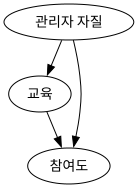

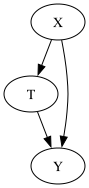

In [21]:
g = gr.Digraph()
g.edge("관리자 자질", "교육")
g.edge("관리자 자질", "참여도")
g.edge("교육", "참여도")
display(g)

g2 = gr.Digraph()
g2.edge("X", "T")
g2.edge("X", "Y")
g2.edge("T", "Y")
display(g2)

### (7) 대리 교란 요인
- 때론 측정되지 않은 교란 요인 때문에 모든 뒷문 경로를 닫을 순 없음
    - 아래 사례에서 관리자의 자질을 측정할 수 없을 경우, 교란 요인에 대한 조건부를 둘 수 없음
    - 따라서 교란편향 때문에 처치가 결과에 미치는 인과효과를 식별할 수 없음
- 그러나, 교란 요인인 관리자 자질에 대한 대리변수로 사용할 수 있는 다른 측정된 변수들
    - 뒷문 경로에는 없는 변수들이지만, 통제하면 편향을 줄이는 데 도움이 됨
    - 이러한 변수들을 대리 교란 요인이라고 부름

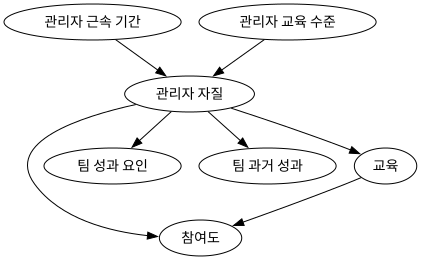

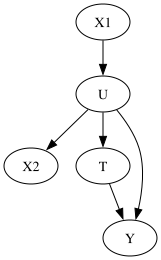

In [35]:
g = gr.Digraph()
g.edge("관리자 근속 기간", "관리자 자질")
g.edge("관리자 교육 수준", "관리자 자질")
g.edge("관리자 자질", "참여도")
g.edge("관리자 자질", "팀 성과 요인")
g.edge("관리자 자질", "팀 과거 성과")
g.edge("관리자 자질", "교육")
g.edge("교육", "참여도")
display(g)

g2 = gr.Digraph()
g2.edge("X1", "U")
g2.edge("U", "X2")
g2.edge("U", "T")
g2.edge("U", "Y")
g2.edge("T", "Y")
display(g2)

### (8) 랜덤화 재해석
- 일반적으로 실무에서 처치를 배정하는 데 어떤 정보를 사용했는지 알고 있으므로 교란 요인이 무엇인지 파악하는 것은 비교적 쉬움
- 만약, 그렇지 않다고 하더라도 처치변수에 개입할 수 있는 옵션은 거의 항상 존재 -> AB 테스트의 핵심
- 처치를 무작위로 배정하면 관측할 수 없는 교란 요인이 있는 그래프에서 처치의 유일한 원인이 랜덤성인 그래프로 바꿀 수 있음
- 결국, 어떤 변수를 조건부로 두어야 효과를 식별할 수 있는지 확인하려고 노력하면서 관심 있는 인과 추정량을 식별 가능한 그래프로 바꿔주는 개입이 무엇인지 확인해야 함
- 모든 공통 원인을 측정할 수 없을 때
    - '측정되지 않은 교란 요인이 분석 결과를 크게 바꾸려면 얼마나 강력해야 하는가?'
    - 민감도 분석의 주요 개념
    혹은, 관심있는 인과 추정량을 정확히 식별할 수 없을 때 관측 가능한 데이터를 사용하여 그 주변에 경계를 설정할 수 있음 -> 부분식별

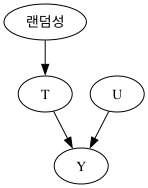

In [24]:
g2 = gr.Digraph()
g2.edge("랜덤성", "T")
g2.edge("T", "Y")
g2.edge("U", "Y")
display(g2)

### (9) 선택편향
#### 9-1. 충돌부 조건부 설정
- 교란편향은 처치와 결과의 공통 원인을 통제하지 않을 때 발생하지만, 선택편향은 공통 효과와 매개자에 대한 조건부와 더 밀접한 관련
- 교란편향을 피하기 위해 무작위로 고객들에게 신규 기능 배포. 고객 중 10%는 무작위로 신규 기능을 사용하고 나머지는 그렇지 않음.
    - 이 기능이 고객 만족도에 영향을 미쳤는지 알기 위해 대리변수로 NPS 사용
    - 그 결과, 신규 기능 사용하고 NPS 설문에 응답한 고객들이 신규 기능을 사용하지 않고 NPS 설문에 응답한 고객들보다 NPS 점수가 높았음 -> 신규기능의 인과효과?
    - NO.
- NPS 설문에 응답한 고객들을 대상으로만 실험군과 대조군 차이를 추정함
    - 랜덤화를 통해 ATE를 실험군과 대조군 간의 결과 차이로 식별할 수 있지만, 공통 효과에 조건부를 두면 선택편향도 생김

#### 9-2. 선택편향 보정
- 선택편향 보정은 쉽지 않음. 무작위 통제 실험을 하더라도 ATE를 식별할 수 없음. 설문에 응답한 사람들을 조건으로 설정하면 신규기능과 고객 만족도 사이의 비인과 연관성 흐름을 차단할 수 없기 때문.
- 추가 가정이 필요하며 여기서 그래프 모델이 가정을 명확하고 투명하게 만듬
- 식별을 위해 결과가 선택을 야기하지 않는다고 가정해야 함
    - 고객 만족도가 고객이 설문에 응답할 가능성을 높이거나 낮추지 않는다는 의미
    - 대신, 선택과 결과 모두를 유발하는 다른 관측 가능한 변수들이 있을 것
    - 고객이 설문조사에 응답하게 하는 유일한 요인은 고객의 앱 사용 시간과 신규 기능일 수 있음
    - 이 경우, 실험군과 대조군 간의 비인과 연관성은 앱 내 사용 시간을 통해 흐름
        - 도메인 지식이 필요. 만약 이 가정이 맞다면 앱 사용 시간을 통제해서 신규 기능이 만족도에 미치는 영향을 식별할 수 있음
    - 보정 공식을 통해, X로 정의된 그룹으로 데이터를 나눠서 실험군과 대조근을 이 그룹 내에서 비교 가능
    - 그 다음 각 그룹의 크기를 가중치로 사용하여 실험군과 대조군 간 그룹 내 비교의 가중평균을 계산. 
    - 일반적으로 선택편향을 보정하려면 선택을 유발하는 모든 요인을 보정해야 하며, 결과나 처치가 직접 선택을 유도하거나 선택과 숨겨진 공통 원인을 공유하지 않는다고 가정해야 함.

#### 9-3. 매개자 조건부 설정
- 지금까지의 선택편향은 불가피한 모집단의 선택 때문에 발생. But, 의도치 않게 선택편향이 발생할 수 있음
- 사례에서 '직급'은 처치(어성)과 결과(임금) 사이의 매개자

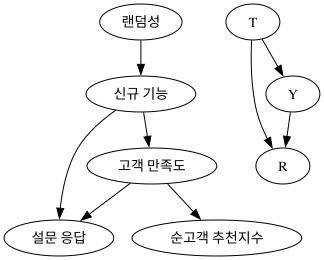

In [26]:
# 충돌부 조건부 설정
g2 = gr.Digraph()
g2.edge("랜덤성", "신규 기능")
g2.edge("신규 기능", "고객 만족도")
g2.edge("신규 기능", "설문 응답")
g2.edge("고객 만족도", "순고객 추천지수")
g2.edge("고객 만족도", "설문 응답")

g2.edge("T", "R")
g2.edge("T", "Y")
g2.edge("Y", "R")
display(g2)

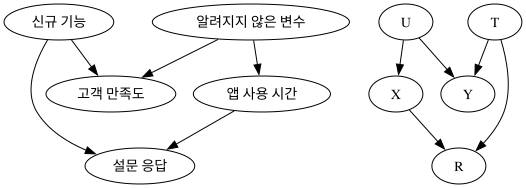

In [29]:
# 선택편향 보정
g2 = gr.Digraph()
g2.edge("신규 기능", "고객 만족도")
g2.edge("신규 기능", "설문 응답")
g2.edge("알려지지 않은 변수", "고객 만족도")
g2.edge("알려지지 않은 변수", "앱 사용 시간")
g2.edge("앱 사용 시간", "설문 응답")

g2.edge("U", "X")
g2.edge("U", "Y")
g2.edge("T", "Y")
g2.edge("T", "R")
g2.edge("X", "R")
display(g2)

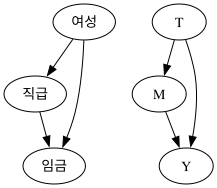

In [33]:
# 매개자 조건부 설정
g2 = gr.Digraph()
g2.edge("여성", "직급")
g2.edge("직급", "임금")
g2.edge("여성", "임금")
# display(g2)

g2.edge("T", "M")
g2.edge("M", "Y")
g2.edge("T", "Y")
display(g2)


- 여성 차별의 한 형태로 여성은 더 높은 직급으로 승진할 가능성이 적다는 그래프
- 남성과 여성의 임금 차이는 부분적으로는 같은 직급에서의 임금 차이일 수 있지만, 직급 자체의 차이에서도 비롯됨
    - 즉, woman -> seniority -> salary 는 처치와 결과 사이의 인과 경로이기도 하므로 분석에서 이 경로를 배제해선 안됨
    - 직급을 통제하면서 남성과 여성의 임금을 비교한다면, 단지 직접적인 차별 woman -> salary 만을 식별할 수 있음

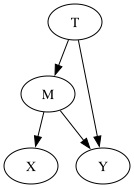

In [36]:
# 매개자 조건부 설정2
g2 = gr.Digraph()
g2.edge("T", "M")
g2.edge("M", "X")
g2.edge("M", "Y")
g2.edge("T", "Y")
display(g2)


- 또한, 매개자의 자식이 조건부로 주어지면 편향을 초래함. 이러한 선택은 인과 경로를 완전히 차단하지는 않지만, 부분적으로 차단함